# Feb07

In [25]:
# import torch
# import os
# import librosa

# model_scripted_ckpt = "/nfs/datab/hungdx/KDW2V-AASISTL/W2V2BASE_AASISTL_DKDLoss_cnsl_audiomentations_3_v10_mobile.pt"
# test_dir = "/nfs/datab/hungdx/KDW2V-AASISTL/test_samples/MobileSamples/EnvironmentalSound_mic&screenrecording_trial_5"
# score = "/nfs/datab/hungdx/KDW2V-AASISTL/test_samples/MobileSamples/EnvironmentalSound_mic&screenrecording_trial_5/W2V2BASE_AASISTL_DKDLoss_cnsl_audiomentations_3_v10_mobile_trim.txt"
# jit_model = torch.jit.load(model_scripted_ckpt)




In [26]:
import pandas
import sys
import os.path
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import eval_metrics_DF as em
from urllib.parse import urlparse

def is_valid_url(url):
    try:
        result = urlparse(url)
        return all([result.scheme, result.netloc])
    except:
        return False


def extract_domain(url):
    # print("Extracting domain from URL: ", url)

    # Check if the url is not valid url
    if not is_valid_url(url):
        return url


    if not isinstance(url, str):
        return None
    netloc = urlparse(url).netloc
    # If the URL is a short version of youtube URL (e.g., youtu.be), handle it
    if 'youtu.be' in netloc or 'youtube.com' in netloc:
        return 'youtube.com'
    # Extract the domain name (e.g., example.com from https://www.example.com/path)
    # Keep subdomains (e.g., sub.example.com)
    domain = netloc

    # domain = netloc.split('.')[-2] + '.' + netloc.split('.')[-1]
    return domain

def eval_to_score_file(score_file, cm_key_file, meta_file, phase):
    # Load the CM key file and the submission scores
    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)

    # Filter CM data for the specific phase
    cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')

    print("Number of scores for phase {}: {}".format(phase, len(cm_scores)))
    # Load meta data
    meta_data = pandas.read_csv(meta_file, sep=',')

    # Prepare meta_data by concatenating 'eval/' with the 'Utterence name (file name)' to match cm_scores format
    meta_data["file_name"] = 'eval/' + meta_data["utt"] + '.wav'

    # Add a 'domain' column to the meta_data by applying the extract_domain function
    meta_data['domain'] = meta_data['Source link'].apply(extract_domain)

    # Merge cm_scores with meta_data
    merged_data = cm_scores.merge(
        meta_data, left_on=0, right_on="file_name", how='inner')
    
    print("Number of scores for phase {} after merging with meta data: {}".format(phase, len(merged_data)))

    # Now you can group by the "group" column in meta_data for further analysis
    grouped = merged_data.groupby("group")

    # Example of iterating over each group and computing EER for each

    group_dict = {}
    for group_name, group_data in grouped:

        bona_cm = group_data[group_data[3] == 'bonafide']['1_x'].values
        spoof_cm = group_data[group_data[3] == 'spoof']['1_x'].values
        
        number_of_bona = len(bona_cm)
        number_of_spoof = len(spoof_cm)

        # Calculate mis classifcation like false positive because we are interested in spoof detection and because we just got bona_cm only


        if len(bona_cm) > 0 and len(spoof_cm) > 0:  # Ensure there's data to compute EER
            eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
            out_data = "Group: {}\tnum_bona:{}\tnum_spoof:{}\teer: {}\tthreshold: {}\n".format(
                group_name, number_of_bona, number_of_spoof,  100*eer_cm, th)

            # Draw the confusion matrix
            y_true = np.concatenate((np.zeros(len(bona_cm)), np.ones(len(spoof_cm))))
            y_score = np.concatenate((bona_cm, spoof_cm))

            # Score < th is predicted as spoof (negative class) and score >= th is predicted as bona (positive class)

            cm = confusion_matrix(y_true, y_score < th)

            # Calculate number of false positives, false negatives
            fn = cm[0][1]
            fp = cm[1][0]



            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bonafide", "spoof"])
            disp.plot()
            plt.title("Group: {}".format(group_name))
            plt.show()

            
            print(out_data)
            group_dict[group_name] = [100*eer_cm, th, fp, fn]
        



    # Return value can be adjusted based on your needs
    return group_dict, grouped

Number of scores for phase eval: 41280
Number of scores for phase eval after merging with meta data: 41280


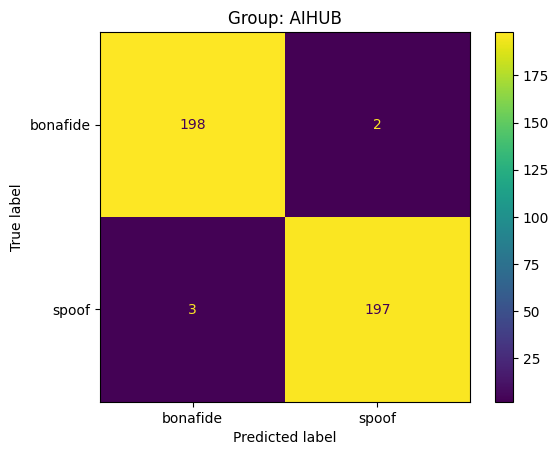

Group: AIHUB	num_bona:200	num_spoof:200	eer: 1.5	threshold: 2.2021820545196533



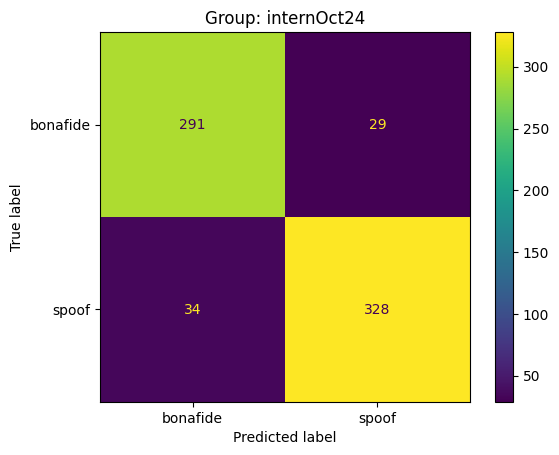

Group: internOct24	num_bona:320	num_spoof:362	eer: 9.383632596685082	threshold: -1.0721241235733032



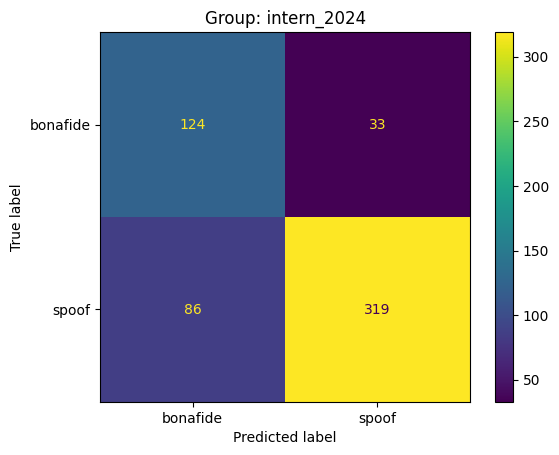

Group: intern_2024	num_bona:157	num_spoof:405	eer: 21.003381300621214	threshold: -3.064600706100464



In [27]:
score_file = '/nfs/datab/hungdx/KDW2V-AASISTL/W2V2BASE_AASISTL_DKDLoss_cnsl_noaudiomentations_best27_feb07.txt'
cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/protocol.txt'
meta_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/df_meta_feb07.csv'
phase = 'eval'
group_dict, grouped = eval_to_score_file(
    score_file, cm_key_file, meta_file, phase)

In [28]:
cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)

# Filter CM data for the specific phase
cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')

print("Number of scores for phase {}: {}".format(phase, len(cm_scores)))
    # Load meta data
meta_data = pandas.read_csv(meta_file, sep=',')

    # Prepare meta_data by concatenating 'eval/' with the 'Utterence name (file name)' to match cm_scores format
meta_data["file_name"] = 'eval/' + meta_data["utt"] + '.wav'

    # Add a 'domain' column to the meta_data by applying the extract_domain function
meta_data['domain'] = meta_data['Source link'].apply(extract_domain)

    # Merge cm_scores with meta_data
merged_data = cm_scores.merge(
        meta_data, left_on=0, right_on="file_name", how='inner')

merged_data.head()


def update_pred(row, conf_threshold, domain, group):
    if row['1_x'] < conf_threshold and row['domain'] == domain and row['group'] == group:
        return 'spoof'
    else:
        return 'bonafide'

def is_valid_domain(domain):
    if "." in domain:
        return True
    return False

for key, value in group_dict.items():
    eer, th, fp, fn = value
    print(f"{key} EER: {eer:.2f}%, Threshold: {th:.2f}, False Positive: {fp}, False Negative: {fn}")

    domains = meta_data['domain'].unique()
    if key == 'intern_2024':
        print("False Positive")
        for domain in domains:
            if not is_valid_domain(domain):
                continue
            # Update predictions based on the threshold
            merged_data['pred'] = merged_data.apply(
                update_pred, args=(th, domain, key), axis=1)

            # Calculate false positives and false negatives
            fn = len(merged_data[(merged_data['pred'] == 'spoof') & (merged_data[3] == 'bonafide') & (
                merged_data['domain'] == domain) & (merged_data['group'] == key)])

            fp = len(merged_data[(merged_data['pred'] == 'bonafide') & (merged_data[3] == 'spoof') & (
                merged_data['domain'] == domain) & (merged_data['group'] == key)])

            # Calculate the false positive rate
            group_domain_length = len(
                merged_data[(merged_data['domain'] == domain) & (merged_data['group'] == key)])
            fp_rate = fp / group_domain_length * 100 if group_domain_length != 0 else 0
            fn_rate = fn / group_domain_length * 100 if group_domain_length != 0 else 0

            print(
                f"{domain} -  {fp} - {fp_rate:.2f}%")

        print()

Number of scores for phase eval: 41280
AIHUB EER: 1.50%, Threshold: 2.20, False Positive: 3, False Negative: 2
internOct24 EER: 9.38%, Threshold: -1.07, False Positive: 34, False Negative: 29
intern_2024 EER: 21.00%, Threshold: -3.06, False Positive: 86, False Negative: 33
False Positive
youtube.com -  25 - 11.74%
clovadubbing.naver.com -  0 - 0.00%
m.sports.naver.com -  0 - 0.00%
app.typecast.ai -  0 - 0.00%
media.naver.com -  0 - 0.00%
elevenlabs.io -  26 - 20.80%
studio.neiro.ai -  0 - 0.00%
www.facebook.com -  0 - 0.00%
app.resemble.ai -  4 - 40.00%
webapp.dubverse.ai -  2 - 25.00%
grad-tts.github.io -  0 - 0.00%
nbviewer.org -  0 - 0.00%
styletts2.github.io -  1 - 20.00%
jik876.github.io -  4 - 57.14%
huggingface.co -  20 - 31.25%
github.com -  3 - 3.45%
voice.ai -  1 - 7.69%
www.kecl.ntt.co.jp -  0 - 0.00%



# In the wild

In [29]:
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em


def eval_to_score_file(score_file, cm_key_file):
    # CM key file is the metadata file that contains the ground truth labels for the eval set
    # score file is the output of the system that contains the scores for the eval set
    # phase is the phase of the eval set (dev or eval)

    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)
    # check here for progress vs eval set
    cm_scores = submission_scores.merge(cm_data, left_on=0, right_on=0, how='inner')
    # cm_scores.head()
    #  0       1_x   1_y      2      3
    #  a.wav  1.234   eval   Music   spoof
    bona_cm = cm_scores[cm_scores['1_y'] == 'bonafide']['1_x'].values
    spoof_cm = cm_scores[cm_scores['1_y'] == 'spoof']['1_x'].values

    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
    out_data = "eer: {}\tthreshold: {}\n".format(100*eer_cm, th)
    print(out_data)
    return eer_cm

In [30]:
score_file = '/nfs/datab/hungdx/KDW2V-AASISTL/supcon_jan22_longR3_epoch_43_in_the_wild.txt'
cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/in_the_wild.txt'



eval_to_score_file(score_file, cm_key_file)

eer: 2.2778953436911777	threshold: -2.33073353767395



0.022778953436911775